# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves.

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

<img src="https://github.com/yandexdataschool/deep_vision_and_graphics/blob/fall22/week02-convnets/cifar10.jpg?raw=1" style="width:80%">

In [ ]:
# **IMPORTANT** when running in colab, un-comment this
# !wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week03_convnets/cifar.py

In [1]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

Dataset not found. Downloading...
(40000, 3, 32, 32) (40000,)


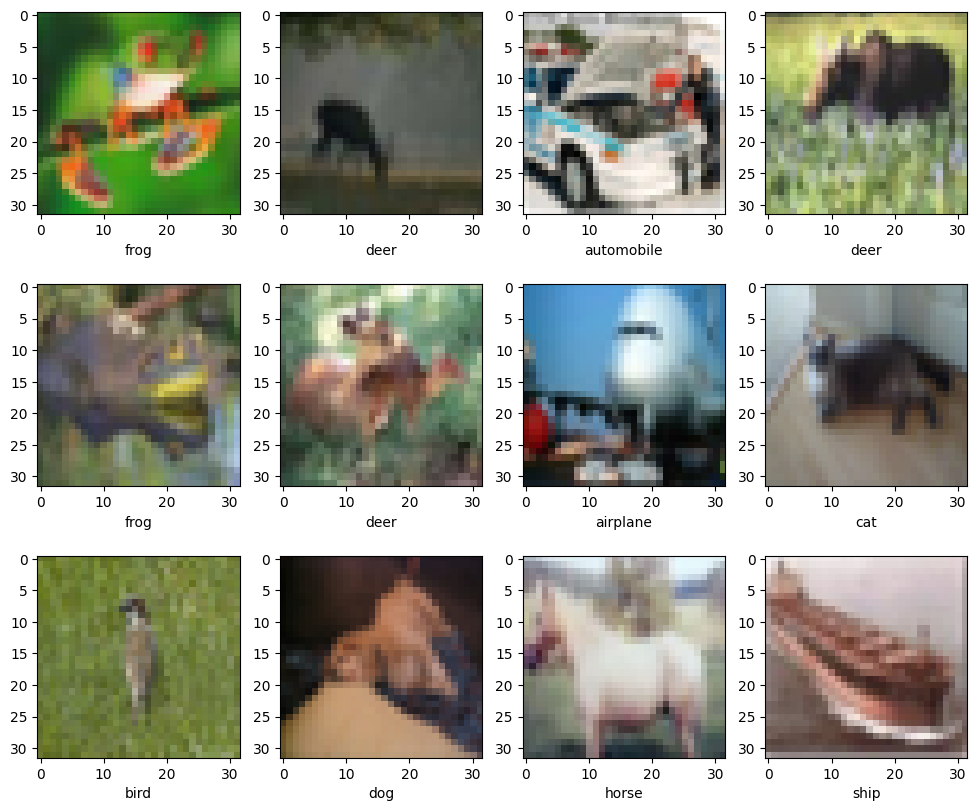

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

Let's start with a dense network for our baseline, then gradually improve it.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

model = nn.Sequential(
    nn.Flatten(),  # reshape images to vectors; if you have conv / pool layers, they go BEFORE flatten
    nn.Linear(3 * 32 * 32, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # logits for 10 classes. No softmax - this is intentional
)

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [9]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [11]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(2.3972, grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [14]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [16]:
import time
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            y_pred = logits.argmax(-1).detach().numpy()
            val_accuracy.append(np.mean(y_batch == y_pred))

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 100 took 0.518s
  training loss (in-iteration): 	2.021551
  validation accuracy: 			33.85 %
Epoch 2 of 100 took 0.351s
  training loss (in-iteration): 	1.848677
  validation accuracy: 			36.17 %
Epoch 3 of 100 took 0.355s
  training loss (in-iteration): 	1.781342
  validation accuracy: 			39.23 %
Epoch 4 of 100 took 0.358s
  training loss (in-iteration): 	1.730551
  validation accuracy: 			39.70 %
Epoch 5 of 100 took 0.373s
  training loss (in-iteration): 	1.689138
  validation accuracy: 			40.95 %
Epoch 6 of 100 took 0.354s
  training loss (in-iteration): 	1.651383
  validation accuracy: 			42.78 %
Epoch 7 of 100 took 0.359s
  training loss (in-iteration): 	1.619815
  validation accuracy: 			42.13 %
Epoch 8 of 100 took 0.351s
  training loss (in-iteration): 	1.593444
  validation accuracy: 			43.84 %
Epoch 9 of 100 took 0.353s
  training loss (in-iteration): 	1.570201
  validation accuracy: 			44.87 %
Epoch 10 of 100 took 0.351s
  training loss (in-iteration): 	1.550938
  v

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [19]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		51.38 %
Achievement unlocked: 60lvl Warlock!


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.




```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [ ]:
from torchvision import transforms
means = np.array((0.4914, 0.4822, 0.4465))  # statistics from dataset documentation
stds = np.array((0.2023, 0.1994, 0.2010))

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [ ]:
from torchvision.datasets import CIFAR10
train_loader = CIFAR10("./cifar_data/", train=True, transform=transform_augment)

train_dataloader = torch.utils.data.DataLoader(
    train_loader,  batch_size=32, shuffle=True, num_workers=1)

In [ ]:

for (x_batch, y_batch) in train_dataloader:

    print('X:', type(x_batch), x_batch.shape)
    print('y:', type(y_batch), y_batch.shape)

    for i, img in enumerate(x_batch.numpy()[:8]):
        plt.subplot(2, 4, i+1)
        plt.imshow(img.transpose([1,2,0]) * stds + means )


    raise NotImplementedError("Plese use this code in your training loop")
    # TODO use this in your training loop

When testing, we don't need random crops, just normalize with same statistics.

In [ ]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

test_loader = <YOUR CODE>

# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.

## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons,
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   
### Data augmemntation
   * getting 5x as large dataset for free is a great
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [ ]:
# you might as well write your solution here :)

In [1]:
import os, math, time, random, json
from dataclasses import dataclass
from typing import Tuple, Dict, Any

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from tqdm import tqdm

import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
def set_seed(seed:int=42, deterministic:bool=False):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.benchmark = True

set_seed(42, deterministic=False)

Using device: cuda


In [2]:
data_root = "./data"

#(computed on the train split)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

def compute_cifar10_mean_std():
    tmp = CIFAR10(root=data_root, train=True, download=True, transform=transforms.ToTensor())
    loader = DataLoader(tmp, batch_size=1024, shuffle=False, num_workers=os.cpu_count() or 2)
    n = 0
    mean = torch.zeros(3)
    M2 = torch.zeros(3)
    for x, _ in loader:
        x = x.view(x.size(0), x.size(1), -1)  # [B, C, H*W]
        batch_mean = x.mean(dim=(0,2))
        batch_var = x.var(dim=(0,2), unbiased=False)
        batch_count = x.shape[0]*x.shape[2]
        delta = batch_mean - mean
        tot_count = n + batch_count
        mean = mean + delta * batch_count / tot_count
        delta2 = batch_mean - mean
        M2 = M2 + batch_var*batch_count + delta*delta2*n*batch_count/tot_count
        n = tot_count
    std = (M2/n).sqrt()
    return tuple(mean.tolist()), tuple(std.tolist())

try:
    from torchvision.transforms import AutoAugment, AutoAugmentPolicy
    train_tfms = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        AutoAugment(policy=AutoAugmentPolicy.CIFAR10),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
except Exception:
    train_tfms = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])

test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

full_train = CIFAR10(root=data_root, train=True, download=True, transform=train_tfms)
test_set   = CIFAR10(root=data_root, train=False, download=True, transform=test_tfms)

val_size = 5000
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(42))

num_workers = min(8, os.cpu_count() or 2)
pin_memory = (device.type == 'cuda')

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s] 


Train: 45000 | Val: 5000 | Test: 10000


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),
        )
    def forward(self, x):
        return self.block(x)

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64),  
            ConvBlock(64, 128), 
            ConvBlock(128, 256),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

baseline_model = SmallCNN().to(device)
sum(p.numel() for p in baseline_model.parameters())/1e6

1.18049

In [4]:
from torchvision.models import resnet18

def make_cifar_resnet18(num_classes=10):
    m = resnet18(weights=None)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

improved_model = make_cifar_resnet18().to(device)
sum(p.numel() for p in improved_model.parameters())/1e6

11.173962

In [5]:
@dataclass
class TrainConfig:
    epochs: int = 30
    lr: float = 3e-3
    weight_decay: float = 5e-4
    label_smoothing: float = 0.05
    mixed_precision: bool = True

def accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss/total, total_correct/total

def fit(model, train_loader, val_loader, cfg: TrainConfig, optimizer, scheduler=None, log_prefix="Model"):
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.mixed_precision and device.type=='cuda'))
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    best_val = 0.0
    best_state = None

    for epoch in range(1, cfg.epochs+1):
        model.train()
        epoch_loss, epoch_acc, n = 0.0, 0.0, 0
        t0 = time.time()
        for xb, yb in tqdm(train_loader):
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            if scaler.is_enabled():
                with torch.cuda.amp.autocast():
                    logits = model(xb)
                    loss = criterion(logits, yb)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
            if scheduler and not isinstance(scheduler, torch.optim.lr_scheduler._LRScheduler):
                scheduler.step()
            bsz = xb.size(0)
            epoch_loss += loss.item() * bsz
            epoch_acc += (logits.argmax(1) == yb).float().sum().item()
            n += bsz
        if scheduler and isinstance(scheduler, torch.optim.lr_scheduler._LRScheduler):
            scheduler.step()

        train_loss, train_acc = epoch_loss/n, epoch_acc/n
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        dt = time.time()-t0
        print(f"{log_prefix} | epoch {epoch:03d}/{cfg.epochs} | "
              f"train loss {train_loss:.4f} acc {train_acc*100:.2f}% | "
              f"val loss {val_loss:.4f} acc {val_acc*100:.2f}% | "
              f"time {dt:.1f}s")

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val

def test_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            logits = model(xb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    test_acc = correct/total
    print(f"TEST accuracy: {test_acc*100:.2f}%")
    return test_acc

In [6]:
cfg = TrainConfig(epochs=30, lr=3e-3, weight_decay=5e-4, label_smoothing=0.05, mixed_precision=True)
baseline_model = SmallCNN().to(device)

opt = torch.optim.AdamW(baseline_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)

baseline_model, best_val = fit(baseline_model, train_loader, val_loader, cfg, opt, scheduler=sched, log_prefix="SmallCNN")
print(f"Best val acc (SmallCNN): {best_val*100:.2f}%")

torch.save(baseline_model.state_dict(), "smallcnn_best.pt")

/tmp/ipykernel_36/2272012306.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.mixed_precision and device.type=='cuda'))
  0%|          | 0/352 [00:00<?, ?it/s]/tmp/ipykernel_36/2272012306.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 352/352 [00:15<00:00, 22.08it/s]


SmallCNN | epoch 001/30 | train loss 1.9297 acc 29.02% | val loss 1.7324 acc 40.44% | time 17.7s


100%|██████████| 352/352 [00:13<00:00, 25.59it/s]


SmallCNN | epoch 002/30 | train loss 1.6124 acc 45.20% | val loss 1.4452 acc 52.60% | time 15.3s


100%|██████████| 352/352 [00:13<00:00, 25.22it/s]


...

SmallCNN | epoch 028/30 | train loss 0.7537 acc 82.59% | val loss 0.7630 acc 81.54% | time 15.3s


100%|██████████| 352/352 [00:13<00:00, 25.46it/s]


SmallCNN | epoch 029/30 | train loss 0.7633 acc 82.03% | val loss 0.8198 acc 79.12% | time 15.4s


100%|██████████| 352/352 [00:13<00:00, 25.51it/s]


SmallCNN | epoch 030/30 | train loss 0.7471 acc 82.64% | val loss 0.7824 acc 81.22% | time 15.3s
Best val acc (SmallCNN): 82.14%


In [7]:
%%time
print("Evaluating SmallCNN on TEST:")
# smallcnn = SmallCNN().to(device)
# smallcnn.load_state_dict(torch.load("smallcnn_best.pt", map_location=device))
test_model(baseline_model, test_loader)

Evaluating SmallCNN on TEST:
TEST accuracy: 87.67%
CPU times: user 343 ms, sys: 178 ms, total: 521 ms
Wall time: 1.22 s


0.8767

In [9]:
epochs = 100 
cfg2 = TrainConfig(epochs=30, lr=3e-3, weight_decay=5e-4, label_smoothing=0.05, mixed_precision=True)
improved_model = make_cifar_resnet18().to(device)

opt2 = torch.optim.AdamW(improved_model.parameters(), lr=cfg2.lr, weight_decay=cfg2.weight_decay)
sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=cfg2.epochs)

improved_model, best_val2 = fit(improved_model, train_loader, val_loader, cfg2, opt2, scheduler=sched2, log_prefix="ResNet18-CIFAR")
print(f"Best val acc (ResNet18-CIFAR): {best_val2*100:.2f}%")

torch.save(improved_model.state_dict(), "resnet18_cifar_best.pt")

/tmp/ipykernel_36/2272012306.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.mixed_precision and device.type=='cuda'))
  0%|          | 0/352 [00:00<?, ?it/s]/tmp/ipykernel_36/2272012306.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 352/352 [00:19<00:00, 18.23it/s]


ResNet18-CIFAR | epoch 001/30 | train loss 1.9735 acc 29.23% | val loss 1.8360 acc 36.68% | time 21.0s


100%|██████████| 352/352 [00:19<00:00, 18.22it/s]


ResNet18-CIFAR | epoch 002/30 | train loss 1.6291 acc 44.68% | val loss 1.4772 acc 50.82% | time 21.0s


100%|██████████| 352/352 [00:19<00:00, 18.20it/s]


...

ResNet18-CIFAR | epoch 028/30 | train loss 0.5985 acc 87.63% | val loss 0.6882 acc 84.62% | time 21.1s


100%|██████████| 352/352 [00:19<00:00, 18.25it/s]


ResNet18-CIFAR | epoch 029/30 | train loss 0.5924 acc 87.78% | val loss 0.6992 acc 83.78% | time 21.0s


100%|██████████| 352/352 [00:19<00:00, 18.24it/s]


ResNet18-CIFAR | epoch 030/30 | train loss 0.5833 acc 88.33% | val loss 0.6915 acc 84.02% | time 21.0s
Best val acc (ResNet18-CIFAR): 84.96%


In [10]:
print("\nEvaluating ResNet-18-CIFAR on TEST:")
# resnet_cifar = make_cifar_resnet18().to(device)
# resnet_cifar.load_state_dict(torch.load("resnet18_cifar_best.pt", map_location=device))
test_model(improved_model, test_loader)


Evaluating ResNet-18-CIFAR on TEST:
TEST accuracy: 90.22%


0.9022

# CIFAR-10 CNN — Short Report

**Goal.** Train one CNN on CIFAR-10 from scratch (no pretraining) and exceed the milestone thresholds; keep TEST set untouched until final eval.

## Data & Setup
- **Dataset:** `torchvision.datasets.CIFAR10` with 45k/5k train/val split; standard per-channel **Normalize**.
- **Augmentations (train):** RandomCrop(32,pad=4) + RandomHorizontalFlip + **AutoAugment(CIFAR10)**.
- **Batch sizes:** train **128**, val **256**, test **256**.
- **Reproducibility:** seed=42; AMP enabled on CUDA (speedup computation).

## Models & Training
### 1) Baseline — SmallCNN
- **Arch:** 3× ConvBlocks (Conv-BN-ReLU ×2 + MaxPool + Dropout) → GAP → 2×FC → 10.
- **Opt/Schedule:** **AdamW** (lr=3e-3, wd=5e-4) + **CosineAnnealingLR** (30 epochs), label smoothing=0.05, AMP on.
- **Results:** **Val 82.14%**, **TEST 87.67%**.

### 2) Improved — ResNet-18 (CIFAR variant, from scratch)
- **Arch:** `resnet18(weights=None)` adapted for CIFAR-10: **conv1=3×3, stride=1**, **no max-pool**, `fc→10`.
- **Opt/Schedule:** AdamW + CosineAnnealingLR (30 epochs), label smoothing=0.05, AMP on.
- **Results:** **Val 84.96%**, **TEST 90.22%**.

## Iteration Path 
1. Quick trial with plain **SGD (lr=0.01)** plateaued ~40% val → switched strategy.
2. **SmallCNN + AdamW+Cosine + AutoAugment + smoothing** → cleared 60% easily; peaked **82.14%/87.67%**.
3. **ResNet-18** from scratch with same recipe → **84.96%/90.22%**.